In [1]:
# load the module
%load_ext autoreload
%autoreload 2

import sys 
import os
sys.path.append("../Qtensor")
sys.path.append("../Qtensor/qtree_git")
sys.path.append("../Qtensor/qtree_git/qtree")
sys.path.append("../classical_benchmarks")
sys.path.append("../Experiments/SetCover")
sys.path.append("../../..")
sys.path.append("..")

import json
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import pickle
import Generating_Problems as Generator
from gurobi_optimods.qubo import solve_qubo
import qubovert as qv
from qubovert.problems import SetCover as qv_SetCover
import matplotlib
from matplotlib.lines import Line2D

matplotlib.rcParams.update(matplotlib.rcParamsDefault)
 
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/' # for latex, you might need to change this


#print(os.environ['PATH'])# = os.environ['PATH'] + 'c:/Library/TeX/texbin/' # for latex, you might need to change this
label_size = 8
# plt.style.use('fivethirtyeight')
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r'\usepackage{dsfont}\usepackage{amsmath}\usepackage{physics}')
#matplotlib.rcParams['text.latex.preamble']=[r'/usepackage{dsfont}/usepackage{amsmath}/usepackage{physics}']
 
pr ={"axes.labelsize": 8,               # LaTeX default is 10pt font.
     'axes.titlesize': 8,               
    "font.size": 8,
    "legend.fontsize": 8,               # Make the legend/label fonts
    "xtick.labelsize": 8,               # a little smaller
    "ytick.labelsize": 8,
    'figure.figsize': (2 * 3.35, 3* 9 * 3.35 / 16), #2.0476
    "errorbar.capsize": 1.5,
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots
    "font.sans-serif": [],    
    }
for k, v in pr.items():
    matplotlib.rcParams[k] = v
   
matplotlib.rcParams["font.family"] = "serif"
# mpl.rcParams["font.serif"] = ["STIX"]
matplotlib.rcParams["mathtext.fontset"] = "stix"

In [30]:
with open(f'../data/nodes_{100}_reg_{3}_graph_{1}_opt_Adam_lr_{0.001}_v2.pkl', 'rb') as file:
    data = pickle.load(file)   

In [29]:
data['interpolation']['p=2']['losses']


[-13.562996885628806,
 -13.773528496810172,
 -13.980782450932413,
 -14.184550290768147,
 -14.384628427485941,
 -14.580820390367231,
 -14.772939381834613,
 -14.960811151379092,
 -15.144277191645239,
 -15.323198243195257,
 -15.49745806908798,
 -15.66696742407228,
 -15.831668094003959,
 -15.991536818552264,
 -16.14658883663548,
 -16.29688071621427,
 -16.442512061345475,
 -16.583625650160783,
 -16.720405573590167,
 -16.853073042000894,
 -16.981879721274687,
 -17.107098744753863,
 -17.22901388512741,
 -17.347907692501003,
 -17.46404962912802,
 -17.577685288995195,
 -17.68902765543944,
 -17.798251051901236,
 -17.905488055283527,
 -18.01082926065463,
 -18.11432548716691,
 -18.21599183860573,
 -18.31581297924612,
 -18.413749029998236,
 -18.50974159294683,
 -18.603719538241542,
 -18.695604309445308,
 -18.785314606796284,
 -18.872770386705465,
 -18.957896170776834,
 -19.040623692499427,
 -19.120893929417544,
 -19.198658577723823,
 -19.273881028726937,
 -19.346536905453465,
 -19.416614214791288,


In [31]:
data['interpolation']['p=2']['losses']


[-13.53797412450641,
 -13.752288552051434,
 -13.963279859279563,
 -14.170737122118597,
 -14.374454210572368,
 -14.574231964756157,
 -14.769880651386153,
 -14.96122271068768,
 -15.148095794471265,
 -15.330356081676108,
 -15.507881836237843,
 -15.680577141940399,
 -15.848375708448298,
 -16.01124459150761,
 -16.169187609811065,
 -16.322248176040674,
 -16.470511199510636,
 -16.61410367744933,
 -16.753193590779407,
 -16.887986779239228,
 -17.018721605808217,
 -17.14566143387504,
 -17.269085212698304,
 -17.389276752869275,
 -17.506513511315067,
 -17.621055832090164,
 -17.73313756413931,
 -17.842958799090617,
 -17.950681181561457,
 -18.056425909707265,
 -18.16027423674172,
 -18.26227005804049,
 -18.36242404627423,
 -18.460718773061366,
 -18.557114305503408,
 -18.651553858847176,
 -18.74396919457362,
 -18.834285556500372,
 -18.922426024721553,
 -19.008315234230494,
 -19.09188245241718,
 -19.17306404032402,
 -19.2518053404542,
 -19.328062042837548,
 -19.401801084119185,
 -19.473001134085987,
 -

### Energies


#### Linear Scale

In [2]:
def get_results(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    energies_list=[]

    for graph in graphs:
        #print(n)
        with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}_v2.pkl', 'rb') as file:
            data = pickle.load(file)   
        energy = data[initialization][f'p={p}']['energy']
        energies_list.append(energy)    
    
    return np.mean(energies_list), np.std(energies_list)

### n=50

{'random_init': [4.45812387447611, 3.7060222866773054, 3.167931857433161, 4.0893362111698845, 5.181360312149851, 2.2349071142363934, 0.8353838175938746, 3.448293576690426, 3.0342324503773606, 3.051467878270713, -1.6877437187707698], 'transition_states': [8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312], 'interpolation': [8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312, 8.729091033339312]}
{'random_init': [10.104665751276217, 9.90873993986924, 8.511587142866208, 7.7990927549150415, 10.166370196804618, 10.429531170680217, 7.951338964066049, 10.749021804295305, 8.45210786344112, 8.693849985716836, 6.220621660048753], 'transition_states': [8.729157945395375, 8.72914623562825, 8.72911200106613, 

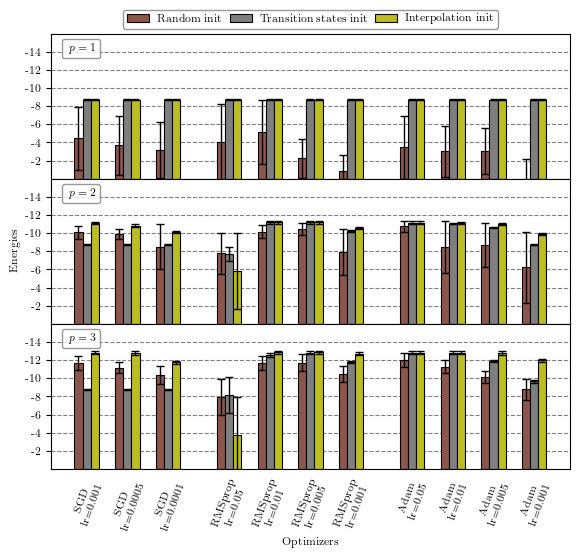

In [8]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 50
initializations = ['random_init', 'transition_states', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

major_yticks_pos = [2, 4, 6, 8, 10, 12, 14]
major_yticks_names = [-i for i in major_yticks_pos]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
      
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00000001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=16)
    elif n ==100:
        ax.set_ylim(bottom=0., top=92)
    elif n ==150:
        ax.set_ylim(bottom=0., top=150)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

sgd 0.0001 fixed, interpol
rms prop 0.005 fixed, interpol
adam 0.05, fixed, interp

#### n = 100

{'random_init': [8.253542132173607, 10.391334786439122, 6.960760208005913, 8.712532376095648, 10.406265600972114, 10.275587321320703, 6.588901480577722, 4.043522544187405, 8.560335592083884, 7.5369122208378005, -5.768052406921386], 'transition_states': [17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614], 'interpolation': [17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614, 17.512889852544614]}
{'random_init': [15.867264598086773, 20.200060377095056, 18.438977889466504, 16.651262551818665, 18.26050801272604, 20.886329545221336, 14.399779230288654, 20.60331083465197, 18.903259028505968, 17.916971087795265, 6.217331175010624], 'transition_states': [17.513104769511894, 17.513048

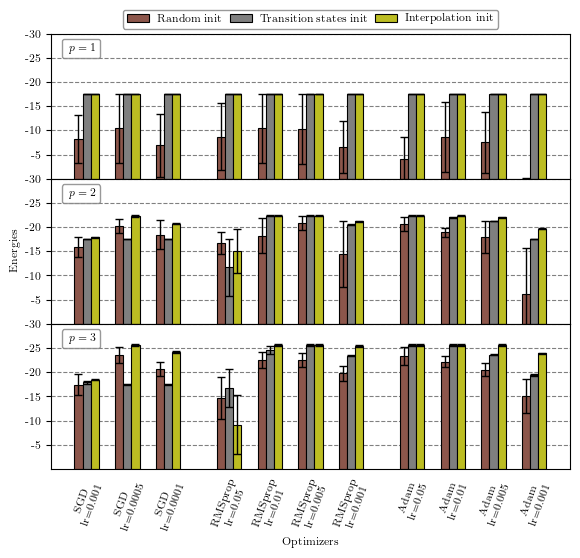

In [14]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 100
initializations = ['random_init', 'transition_states', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan', 'lawngreen', 'crimson']
width = 0.2
multiplier = 0

major_yticks_pos = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80]
major_yticks_names = [-i for i in major_yticks_pos]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
      
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00000001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=50)
    elif n ==100:
        ax.set_ylim(bottom=0., top=30)
    elif n ==150:
        ax.set_ylim(bottom=0., top=150)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

#### n = 150

{'random_init': [8.301575299945496, 19.917404687310256, 13.280848759452692, 15.116089396826746, 17.775803784454922, 11.35863783988877, 10.428820621313744, 15.568812882337735, 13.392954955965772, 10.583293474000758, -4.887598801243381], 'transition_states': [26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186], 'interpolation': [26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186, 26.332076369119186]}
{'random_init': [15.216993176744671, 28.41262688193884, 29.393655862783152, 22.592686848521566, 28.28718420899392, 30.50508498957455, 23.62296706335072, 31.93535448190092, 29.80939225719618, 26.549147416110095, 14.898406806375636], 'transition_states': [10.717979786793936, 26.33223

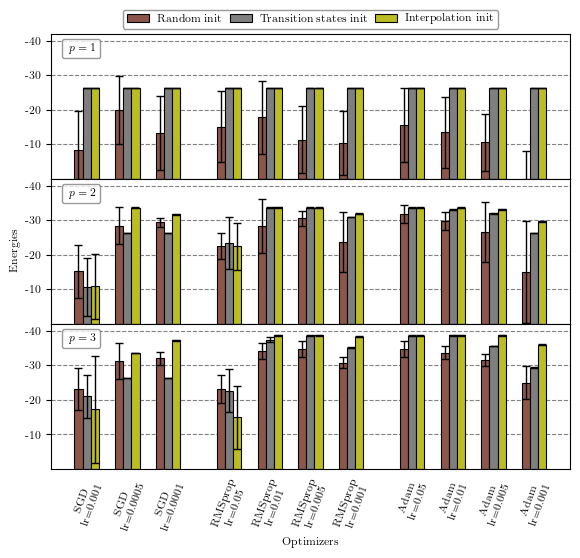

In [18]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 150
initializations = ['random_init', 'transition_states', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

major_yticks_pos = [10, 20, 30, 40, 60, 80, 100, 120, 140]
major_yticks_names = [-i for i in major_yticks_pos]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
      
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00000001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=40)
    elif n ==100:
        ax.set_ylim(bottom=0., top=92)
    elif n ==150:
        ax.set_ylim(bottom=0., top=42)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

#### n = 200

{'random_init': [2.164024011104948, 15.55191324735062, 20.584883726883884, 18.833559042384344, 12.300451629882406, 20.706745773215783, 10.407946438865531, 23.617045077230777, 17.187903183917257, 7.362825121396388, 2.816153151447724], 'transition_states': [35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326], 'interpolation': [35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326, 35.10608358260326]}
{'random_init': [8.584836856120907, 29.432590421117176, 40.22697257444297, 34.1201481849394, 40.059653731852826, 41.0145073214546, 32.87491818851713, 39.62021176284984, 35.93892676602742, 38.59016825148001, 13.143539823336619], 'transition_states': [4.7171143808290825, 35.106331557430245, 35.1062209803608

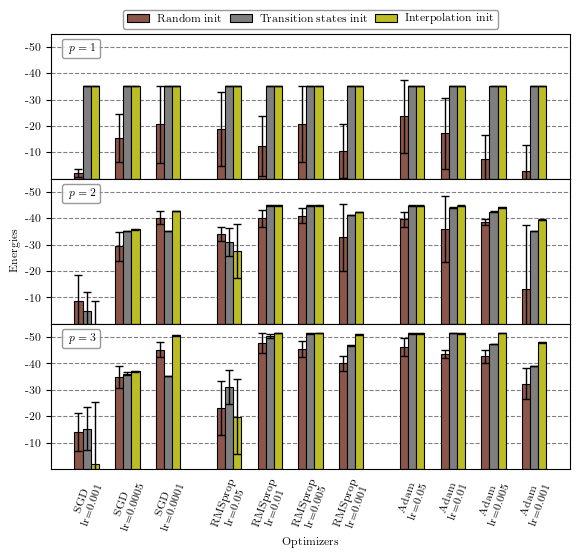

In [20]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 200
initializations = ['random_init', 'transition_states', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

major_yticks_pos = [10, 20, 30, 40, 50]
major_yticks_names = [-i for i in major_yticks_pos]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
      
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00000001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=50)
    elif n ==100:
        ax.set_ylim(bottom=0., top=92)
    elif n ==150:
        ax.set_ylim(bottom=0., top=150)
    elif n ==200:
        ax.set_ylim(bottom=0., top=55)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

#### Log Scale

In [240]:
def get_results(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    energies_list=[]

    for graph in graphs:
        #print(n)
        with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}_v2.pkl', 'rb') as file:
            data = pickle.load(file)   
        energy = data[initialization][f'p={p}']['energy']
        if energy>=-1:
            energy = -1.001
        energies_list.append(energy)    
    
    return np.mean(energies_list), np.std(energies_list)

{'random_init': [0.10119548790172057, 0.15796793708734677, 0.5159954719827166, 0.35755322555511365, 0.5713605560333959, 0.45959350342961597, 0.45260375316481755, 0.5703839654426357, 0.5703584501792414, 0.5406744627579022, 0.19733735047224849], 'transition_states': [0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521], 'fixed_angles_optimization': [0.15782394811894193, 0.013796083548481932, 0.5717409887568516, 0.38100405647675606, 0.5717409887562921, 0.5717409887568516, 0.5717296691229562, 0.5702873575269577, 0.571688169755284, 0.5711137007930526, 0.5560768462724747], 'interpolation': [0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521]}




{'random_init': 

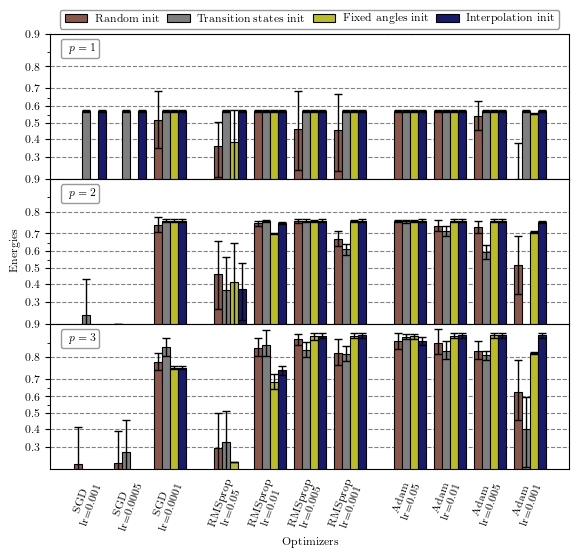

In [242]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 100
initializations = ['random_init', 'transition_states', 'fixed_angles_optimization', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

major_yticks_pos = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
major_yticks_names = [-10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, -130, -140, -150]


major_yticks_pos = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
major_yticks_names = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
major_yticks_names_2 = [None for _ in range(len(major_yticks_pos))]
minor_yticks_pos = [0.55, 0.6, 0.65, 0.7, 0.8, 0.85]
minor_ticks_names = [None for _ in range(len(minor_yticks_pos))]


fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean/n)
                    if (-mean-error) >=1:
                        error_dic[str(initialization)].append(error/n)
                    else:
                        error_dic[str(initialization)].append(0.000001)

                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for key, item in data_dic.items():
        print()
    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    ax.set_yscale('logit')
    #ax1.gca()
    ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=50)
    elif n ==100:
        ax.set_ylim(bottom=0.2, top=0.900001)
    elif n ==150:
        ax.set_ylim(bottom=0., top=150)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    ax.set_yticks(major_yticks_pos, major_yticks_names)
    ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]

axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Fixed angles init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

### Losses

In [21]:
def get_losses(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    losses_list=[]

    try:
        for graph in graphs:
            #print(n)
            with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}_v2.pkl', 'rb') as file:
                data = pickle.load(file)   
            losses = data[initialization][f'p={p}']['losses']
            losses_list.append(losses)   

        arrays = [np.array(x) for x in losses_list] 
        mean = [np.mean(k) for k in zip(*arrays)]
        error = [np.std(k) for k in zip(*arrays)]
    
        return mean, error
    except:
        return [], []


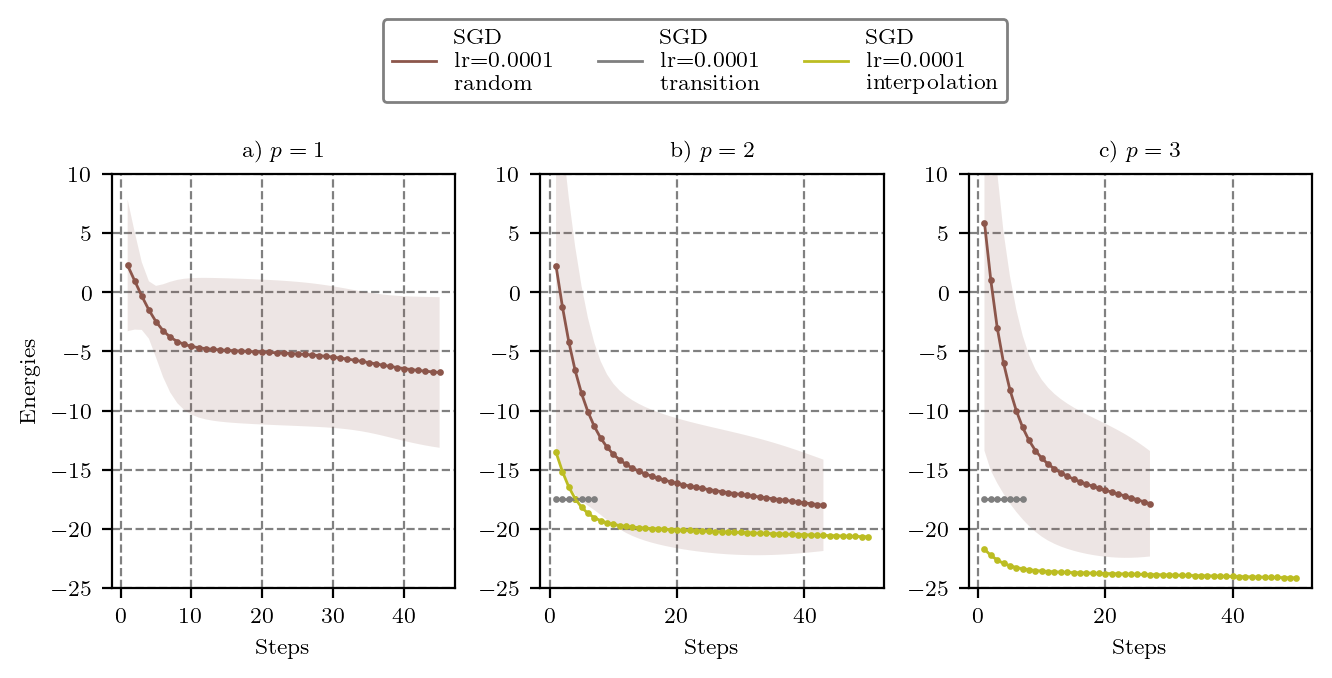

In [25]:
n=100
ps = [1, 2, 3]
labels = []
arguments = [
            #[0.01, 'Adam', 'fixed_angles_optimization'],
            #[0.0001, 'SGD', 'fixed_angles'], 
            #[0.05, 'Adam', 'random_init'],
            #[0.05, 'Adam', 'fixed_angles_optimization'], 
            #[0.05, 'Adam', 'interpolation'], 
            #[0.001, 'RMSprop', 'fixed_angles_optimization'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.01, 'RMSprop', 'transition_states'],
            [0.0001, 'SGD', 'random_init'], 
            [0.0001, 'SGD', 'transition_states'],
            [0.0001, 'SGD', 'interpolation'],
            ]
fig, axs = plt.subplots(1, 3, dpi=200, layout='tight', figsize=(2 * 3.35, 1.5* 9 * 3.35 / 16))
for p in ps:
    for idx, argument in enumerate(arguments):
        if argument[2] == 'random_init':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nrandom')
        elif argument[2] == 'transition_states':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ntransition')
        elif argument[2] == 'fixed_angles_optimization':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nfixed angles')
        elif argument[2] == 'interpolation':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ninterpolation')
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        # for index, max in enumerate(error_max):
        #     if max>1:
        #         error_max[index] = 0.99999
        axs[p-1].fill_between(range(1, len(mean)+1), error_min, error_max, alpha = 0.15, color = colors[idx+6], edgecolor = None)

for p in ps:
    for idx, argument in enumerate(arguments):
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        axs[p-1].scatter(range(1, len(mean)+1), mean, s=2, label='_nolegend_', color=colors[idx+6])
        axs[p-1].plot(range(1, len(mean)+1), mean, linestyle='solid', linewidth=1, label=labels[idx], color=colors[idx+6])
        
        axs[p-1].set_xlabel('Steps')
        axs[p-1].set_axisbelow(True)
        axs[p-1].yaxis.grid(color='gray', linestyle='dashed')
        axs[p-1].xaxis.grid(color='gray', linestyle='dashed')
        axs[p-1].set_ylim(bottom=-25, top=10)
        



axs[0].set_ylabel('Energies')
axs[0].set_title('a) $p = 1$', loc='center')
axs[1].set_title('b) $p = 2$', loc='center')
axs[2].set_title('c) $p = 3$', loc='center')

plt.tight_layout()
axs[1].legend(loc='upper center', ncols=6, bbox_to_anchor=(0.45, 1.4), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)


#ax1.set_yscale('logit')
#ax1.yaxis.set_ticklabels([])
#ax1.set_ylim(bottom=0.79, top=0.9997)
#ax1.set_yticks(major_yticks_pos, major_yticks_names)
#ax1.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)


plt.show()

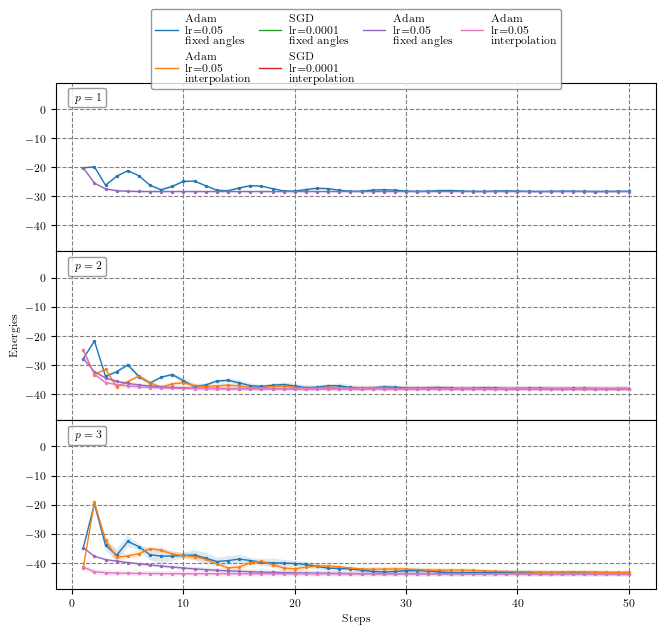

In [274]:
n=50
ps = [1, 2, 3]
labels = []
arguments = [
            #[0.01, 'Adam', 'fixed_angles_optimization'],
            #[0.0001, 'SGD', 'fixed_angles'], 
            #[0.05, 'Adam', 'random_init'],
            [0.05, 'Adam', 'fixed_angles_optimization'], 
            [0.05, 'Adam', 'interpolation'], 
            #[0.001, 'RMSprop', 'fixed_angles_optimization'], 
            [0.005, 'RMSprop', 'fixed_angles'], 
            [0.005, 'RMSprop', 'fixed_angles'], 
            #[0.01, 'RMSprop', 'transition_states'],
            [0.0001, 'SGD', 'fixed_angles_optimization'], 
            #[0.0001, 'SGD', 'random_init'], 
            #[0.0001, 'SGD', 'transition_states'],
            [0.0001, 'SGD', 'interpolation'],
            ]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)
for p in ps:
    for idx, argument in enumerate(arguments):
        if argument[2] == 'random_init':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nrandom')
        elif argument[2] == 'transition_states':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ntransition')
        elif argument[2] == 'fixed_angles_optimization':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nfixed angles')
        elif argument[2] == 'interpolation':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ninterpolation')
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        # for index, max in enumerate(error_max):
        #     if max>1:
        #         error_max[index] = 0.99999
        axs[p-1].fill_between(range(1, len(mean)+1), error_min, error_max, alpha = 0.15, color = colors[idx], label = '_nolegend_', edgecolor = None)

for p in ps:
    for idx, argument in enumerate(arguments):
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        axs[p-1].scatter(range(1, len(mean)+1), mean, s=2, label='_nolegend_', color=colors[idx])
        axs[p-1].plot(range(1, len(mean)+1), mean, linestyle='solid', linewidth=1, label=labels[idx], color=colors[idx])
        
        ##axs[p-1].set_ylabel('Energies')
        axs[p-1].set_axisbelow(True)
        axs[p-1].yaxis.grid(color='gray', linestyle='dashed')
        axs[p-1].xaxis.grid(color='gray', linestyle='dashed')
        axs[p-1].set_ylim(bottom=-49, top=9)
        axs[p-1].label_outer()
        


axs[1].set_ylabel('Energies', y = 0.5)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)


axs[2].set_xlabel('Steps')
# axs[0].set_title('a) $p = 1$', loc='center')
# axs[1].set_title('b) $p = 2$', loc='center')
# axs[2].set_title('c) $p = 3$', loc='center')

plt.tight_layout()

plt.legend(labels = labels, bbox_to_anchor=(0.5, 3.2), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)

#axs[0].legend(loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.6), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)


#ax1.set_yscale('logit')
#ax1.yaxis.set_ticklabels([])
#ax1.set_ylim(bottom=0.79, top=0.9997)
#ax1.set_yticks(major_yticks_pos, major_yticks_names)
#ax1.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)


plt.show()

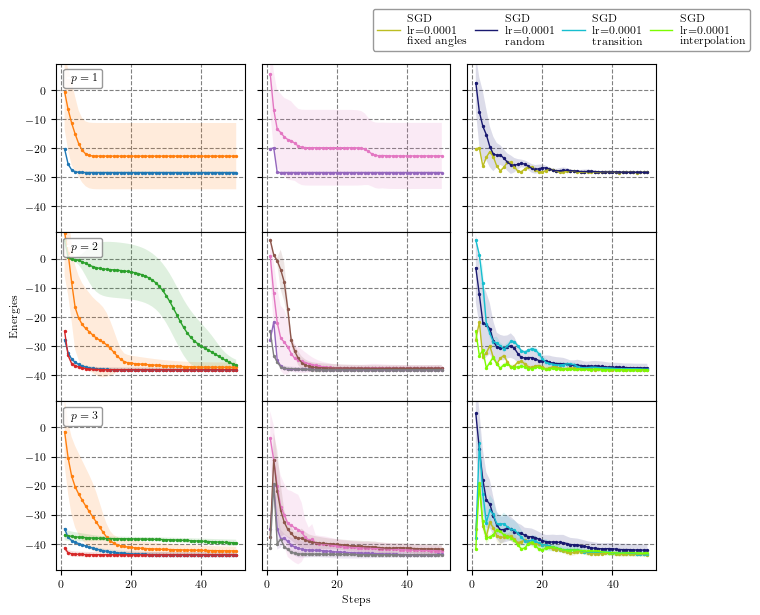

In [306]:
n=50
ps = [1, 2, 3]
labels = []
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan', 'lawngreen', 'crimson']

arguments = [
             [[0.0001, 'SGD', 'fixed_angles_optimization'], 
            [0.0001, 'SGD', 'random_init'], 
            [0.0001, 'SGD', 'transition_states'],
            [0.0001, 'SGD', 'interpolation']],

            [[0.005, 'RMSprop', 'fixed_angles_optimization'], 
            [0.005, 'RMSprop', 'random_init'], 
            [0.005, 'RMSprop', 'transition_states'],
            [0.005, 'RMSprop', 'interpolation']],

            [[0.05, 'Adam', 'fixed_angles_optimization'], 
            [0.05, 'Adam', 'random_init'], 
            [0.05, 'Adam', 'transition_states'],
            [0.05, 'Adam', 'interpolation']]

            #[0.01, 'Adam', 'fixed_angles_optimization'],
            #[0.0001, 'SGD', 'fixed_angles'], 
            #[0.05, 'Adam', 'random_init'],
            #[0.05, 'Adam', 'fixed_angles_optimization'], 
            #[0.05, 'Adam', 'interpolation'], 
            #[0.001, 'RMSprop', 'fixed_angles_optimization'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.01, 'RMSprop', 'transition_states'],
            #[0.0001, 'SGD', 'fixed_angles_optimization'], 
            #[0.0001, 'SGD', 'random_init'], 
            #[0.0001, 'SGD', 'transition_states'],
            #[0.0001, 'SGD', 'interpolation'],
            ]

fig = plt.figure()
gs = fig.add_gridspec(3, 3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)
for p in ps:
    labels = []
    counter = 0
    for column in [0, 1, 2]:
        for idx, argument in enumerate(arguments[column]):
            if argument[2] == 'random_init':
                labels.append(f'{argument[1]}\nlr={argument[0]}\nrandom')
            elif argument[2] == 'transition_states':
                labels.append(f'{argument[1]}\nlr={argument[0]}\ntransition')
            elif argument[2] == 'fixed_angles_optimization':
                labels.append(f'{argument[1]}\nlr={argument[0]}\nfixed angles')
            elif argument[2] == 'interpolation':
                labels.append(f'{argument[1]}\nlr={argument[0]}\ninterpolation')
            mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
            
            error_min = [i-j for i,j in zip(mean, error)]
            error_max = [i+j for i, j in zip(mean, error)]
            # for index, max in enumerate(error_max):
            #     if max>1:
            #         error_max[index] = 0.99999
            axs[p-1][column].fill_between(range(1, len(mean)+1), error_min, error_max, alpha = 0.15, color = colors[counter], label = '_nolegend_', edgecolor = None)
            counter +=1
for p in ps:
    counter = 0
    for column in [0, 1, 2]:
        for idx, argument in enumerate(arguments[column]):
            mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
            axs[p-1][column].scatter(range(1, len(mean)+1), mean, s=2, label='_nolegend_', color=colors[counter])
            axs[p-1][column].plot(range(1, len(mean)+1), mean, linestyle='solid', linewidth=1, label=labels[counter], color=colors[counter])
            
            ##axs[p-1].set_ylabel('Energies')
            axs[p-1][column].set_axisbelow(True)
            axs[p-1][column].yaxis.grid(color='gray', linestyle='dashed')
            axs[p-1][column].xaxis.grid(color='gray', linestyle='dashed')
            axs[p-1][column].set_ylim(bottom=-49, top=9)
            axs[p-1][column].label_outer()
            counter +=1
        


axs[1][0].set_ylabel('Energies', y = 0.5)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0][0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1][0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
axs[2][0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))

#l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
#axs[2][0].add_artist(l1)


axs[2][1].set_xlabel('Steps')
# axs[0].set_title('a) $p = 1$', loc='center')
# axs[1].set_title('b) $p = 2$', loc='center')
# axs[2].set_title('c) $p = 3$', loc='center')

plt.tight_layout()
plt.legend(labels = labels, bbox_to_anchor=(0.5, 3.2), loc = 'center', ncols = 8, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)

#axs[0].legend(loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.6), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)


#ax1.set_yscale('logit')
#ax1.yaxis.set_ticklabels([])
#ax1.set_ylim(bottom=0.79, top=0.9997)
#ax1.set_yticks(major_yticks_pos, major_yticks_names)
#ax1.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)


plt.show()